
Our dataset consists of clinical data from patients who entered the hospital complaining of chest pain ("angina") during exercise.  The information collected includes:

* `age` : Age of the patient

* `sex` : Sex of the patient

* `cp` : Chest Pain type

    + Value 0: asymptomatic
    + Value 1: typical angina
    + Value 2: atypical angina
    + Value 3: non-anginal pain
   
    
* `trtbps` : resting blood pressure (in mm Hg)

* `chol` : cholesterol in mg/dl fetched via BMI sensor

* `restecg` : resting electrocardiographic results

    + Value 0: normal
    + Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
    + Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria

* `thalach` : maximum heart rate achieved during exercise

* `output` : the doctor's diagnosis of whether the patient is at risk for a heart attack
    + 0 = not at risk of heart attack
    + 1 = at risk of heart attack

In [1]:
import pandas as pd
import numpy as np

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import f1_score, roc_auc_score

import matplotlib.pyplot as plt

ha = pd.read_csv("https://www.dropbox.com/s/aohbr6yb9ifmc8w/heart_attack.csv?dl=1")
ha.head()


,age,sex,cp,trtbps,chol,restecg,thalach,output
0,63,1,3,145,233,0,150,1
1,37,1,2,130,250,1,187,1
2,56,1,1,120,236,1,178,1
3,57,0,0,120,354,1,163,1
4,57,1,0,140,192,1,148,1


In [ ]:
ha = pd.read_csv("https://www.dropbox.com/s/aohbr6yb9ifmc8w/heart_attack.csv?dl=1")

## Q1: Natural Multiclass Models

Fit a multiclass KNN, Decision Tree, and LDA for the heart disease data; this time predicting the type of chest pain (categories 0 - 3) that a patient experiences.  For the decision tree, plot the fitted tree, and interpret the first couple splits.


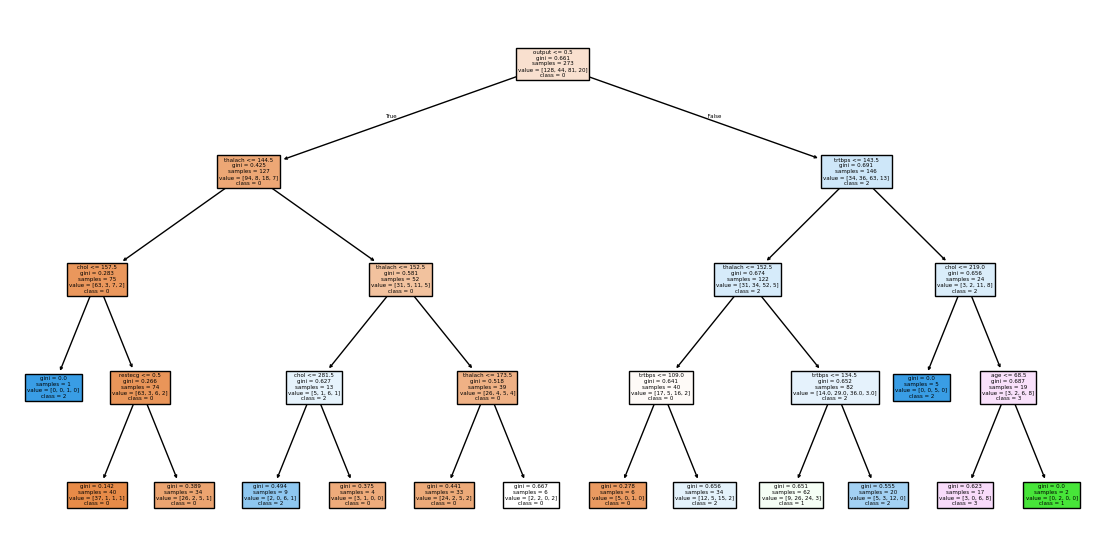

In [2]:
X = ha.drop(columns=["cp"])
y = ha["cp"]

knn = KNeighborsClassifier()
knn.fit(X, y)

tree = DecisionTreeClassifier(max_depth=4)
tree.fit(X, y)

lda = LinearDiscriminantAnalysis()
lda.fit(X, y)

plt.figure(figsize=(14,7))
plot_tree(tree, feature_names=X.columns, class_names=["0","1","2","3"], filled=True)
plt.show()


The first split in the tree is on output, which means the model first checks whether the patient is at risk of a heart attack or not. After that, for people not at risk, the next split is based on their maximum heart rate. For people at risk, the next split is based on their resting blood pressure.

So basically, the tree first separates patients by risk level, and then uses heart rate or blood pressure to figure out their chest pain type.


## Q2:  OvR

Create a new column in the `ha` dataset called `cp_is_3`, which is equal to `1` if the `cp` variable is equal to `3` and `0` otherwise.

Then, fit a Logistic Regression to predict this new target, and report the **F1 Score**.

Repeat for the other three `cp` categories.  Which category was the OvR approach best at distinguishing?

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

f1_scores = {}

for c in [0, 1, 2, 3]:
    ha["cp_is_"+str(c)] = (ha["cp"] == c).astype(int)
    y = ha["cp_is_"+str(c)]
    X = ha.drop(columns=["cp", "cp_is_"+str(c)])

    model = LogisticRegression(max_iter=1000)
    model.fit(X, y)

    preds = model.predict(X)
    f1_scores[c] = f1_score(y, preds)

f1_scores


{0: 0.7364341085271318, 1: 0.0, 2: 0.8888888888888888, 3: 0.7878787878787878}

For the OvR logistic models, the F1 scores were about 0.74 for cp = 0, 0.00 for cp = 1, 0.89 for cp = 2, and 0.79 for cp = 3.
The OvR approach worked best for cp = 2 (highest F1 score), and it struggled the most for cp = 1 (F1 score = 0).

## Q3: OvO

Reduce your dataset to only the `0` and `1` types of chest pain.

Then, fit a Logistic Regression to predict between the two groups, and report the **ROC-AUC**.  

Repeat comparing category `0` to `2` and `3`.  Which pair was the OvO approach best at distinguishing?

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

pairs = [(0,1), (0,2), (0,3)]
auc_scores = {}

for a, b in pairs:
    sub = ha[(ha["cp"] == a) | (ha["cp"] == b)]
    X = sub.drop(columns=["cp"])
    y = (sub["cp"] == b).astype(int)

    model = LogisticRegression(max_iter=1000)
    model.fit(X, y)

    probs = model.predict_proba(X)[:,1]
    auc_scores[(a,b)] = roc_auc_score(y, probs)

auc_scores


{(0, 1): np.float64(1.0), (0, 2): np.float64(1.0), (0, 3): np.float64(1.0)}

All three pairs (0 vs 1, 0 vs 2, and 0 vs 3) had an ROC-AUC of 1.0.
This means the logistic regression model was able to perfectly separate the two chest-pain categories in every pair.
So the OvO approach worked equally well for all three comparisons.